In [2]:
import cupy as cp
import numpy as np

In [3]:
T = 100
mu = 1
epsilon = 1
def f(r):
    return cp.pi-r

def wall_rep(r):
    return 1/r+1/(r-2*cp.pi)

In [4]:
def simulate_paths(n_paths, n_steps, T=100):
    dt = T/n_steps
    X_s = cp.zeros((n_paths, n_steps+1))
    X_s[:, 0] = cp.pi
    W_s = cp.sqrt(dt) * cp.random.normal(size=(n_paths, n_steps))
    
    for i in range(n_steps):
        X_s[:, i+1] = X_s[:, i] + 2*(f(X_s[:, i])+wall_rep(X_s[:, i]))*dt  + 2*W_s[:, i]
    
    return X_s.get()

In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define your drift pieces on GPU
# -------------------------------------------------
def f(r):
    return cp.pi - r

def wall_rep(r):
    return 1.0 / r + 1.0 / (r - 2.0 * cp.pi)

# -------------------------------------------------
# Logarithmic step grid: 1, 5, 10, 50, 100, ...
# -------------------------------------------------
def make_step_grid(max_steps=10**6):
    vals = [1]
    k = 0
    while True:
        a = 5 * (10**k)
        b = 10 * (10**k)
        if a <= max_steps:
            vals.append(a)
        if b <= max_steps:
            vals.append(b)
        if b >= max_steps:
            break
        k += 1
    return sorted(set(vals))

# -------------------------------------------------
# Maximum parallel paths that fit on GPU
# Only depends on per-path state, not on n_steps
# -------------------------------------------------
def max_parallel_paths(safety=0.85, dtype=cp.float32):
    free_bytes, total_bytes = cp.cuda.Device().mem_info
    usable_bytes = int(free_bytes * safety)

    # Per path we keep roughly:
    # x                : float
    # noise            : float
    # x_new            : float
    # active mask      : bool
    # escaped mask/tmp : bool
    #
    # Use a conservative estimate
    itemsize = cp.dtype(dtype).itemsize
    bytes_per_path = 3 * itemsize + 2 * 1 + 16

    n_paths = usable_bytes // bytes_per_path
    return max(1, int(n_paths))

# -------------------------------------------------
# Simulate one batch on GPU without storing paths
# Returns number of escaped paths in this batch
# -------------------------------------------------
def escaped_in_one_batch(n_paths, n_steps, T=100.0, mu=1, epsilon=1, dtype=cp.float32):
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    sqrt_epsilon = np.sqrt(epsilon)

    x = cp.full(n_paths, cp.pi, dtype=dtype)
    active = cp.ones(n_paths, dtype=cp.bool_)

    n_escaped = 0

    lower = dtype(0.0)
    upper = dtype(2.0 * np.pi)

    for _ in range(n_steps):
        n_active = int(active.sum().item())
        if n_active == 0:
            break

        idx = cp.where(active)[0]
        x_active = x[idx]

        dW = sqrt_dt * cp.random.standard_normal(n_active, dtype=dtype)

        x_new = x_active + 2.0 * mu * (f(x_active) + wall_rep(x_active)) * dt + 2.0 * sqrt_epsilon * dW

        escaped_now = (x_new <= lower) | (x_new >= upper)

        n_escaped += int(escaped_now.sum().item())
        survivors = ~escaped_now
        x[idx[survivors]] = x_new[survivors]
        active[idx[escaped_now]] = False

    return n_escaped

# -------------------------------------------------
# Run total_paths by repeatedly using the largest
# batch size that fits on GPU
# -------------------------------------------------
def escape_percentage_for_steps(total_paths, n_steps, T=100.0, mu=0.01, epsilon=0.01,
                                dtype=cp.float32, safety=0.85):
    batch_size = max_parallel_paths(safety=safety, dtype=dtype)

    done = 0
    total_escaped = 0

    while done < total_paths:
        current_batch = min(batch_size, total_paths - done)

        escaped_batch = escaped_in_one_batch(
            n_paths=current_batch,
            n_steps=n_steps,
            T=T,
            mu=mu,
            epsilon=epsilon,
            dtype=dtype
        )

        total_escaped += escaped_batch
        done += current_batch

        cp.get_default_memory_pool().free_all_blocks()

        print(f"n_steps={n_steps}, done={done}/{total_paths}, escaped={total_escaped}")

    return 100.0 * total_escaped / total_paths, batch_size


In [6]:

# -------------------------------------------------
# Sweep over step sizes
# -------------------------------------------------
total_paths = 10**7
step_grid = make_step_grid(10**6)

escape_percentages = []
batch_sizes = []

for n_steps in step_grid:
    pct, batch_size = escape_percentage_for_steps(
        total_paths=total_paths,
        n_steps=n_steps,
        T=100.0,
        mu=0.01,
        epsilon=0.01,
        dtype=cp.float32,   # float32 gives more parallel paths
        safety=0.85
    )
    escape_percentages.append(pct)
    batch_sizes.append(batch_size)

    print(f"Finished n_steps={n_steps}, escape percentage={pct:.6f}%, batch_size={batch_size}")

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.semilogx(step_grid, escape_percentages, marker="o")
plt.xlabel("Number of steps")
plt.ylabel("Escaped paths (%)")
plt.title("Escape percentage vs number of steps")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

n_steps=1, done=10000000/10000000, escaped=1163472
Finished n_steps=1, escape percentage=11.634720%, batch_size=209571894
n_steps=5, done=10000000/10000000, escaped=88536
Finished n_steps=5, escape percentage=0.885360%, batch_size=209453056
n_steps=10, done=10000000/10000000, escaped=35256
Finished n_steps=10, escape percentage=0.352560%, batch_size=209453056
n_steps=50, done=10000000/10000000, escaped=13030
Finished n_steps=50, escape percentage=0.130300%, batch_size=209453056
n_steps=100, done=10000000/10000000, escaped=10797
Finished n_steps=100, escape percentage=0.107970%, batch_size=209453056
n_steps=500, done=10000000/10000000, escaped=7729
Finished n_steps=500, escape percentage=0.077290%, batch_size=209453056
n_steps=1000, done=10000000/10000000, escaped=7101
Finished n_steps=1000, escape percentage=0.071010%, batch_size=209453056
n_steps=5000, done=10000000/10000000, escaped=5956
Finished n_steps=5000, escape percentage=0.059560%, batch_size=209453056


KeyboardInterrupt: 

In [1]:
# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.semilogx(step_grid[2:], escape_percentages[2:], marker="o")
plt.xlabel("Number of steps")
plt.ylabel("Escaped paths (%)")
plt.title("Escape percentage vs number of steps")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

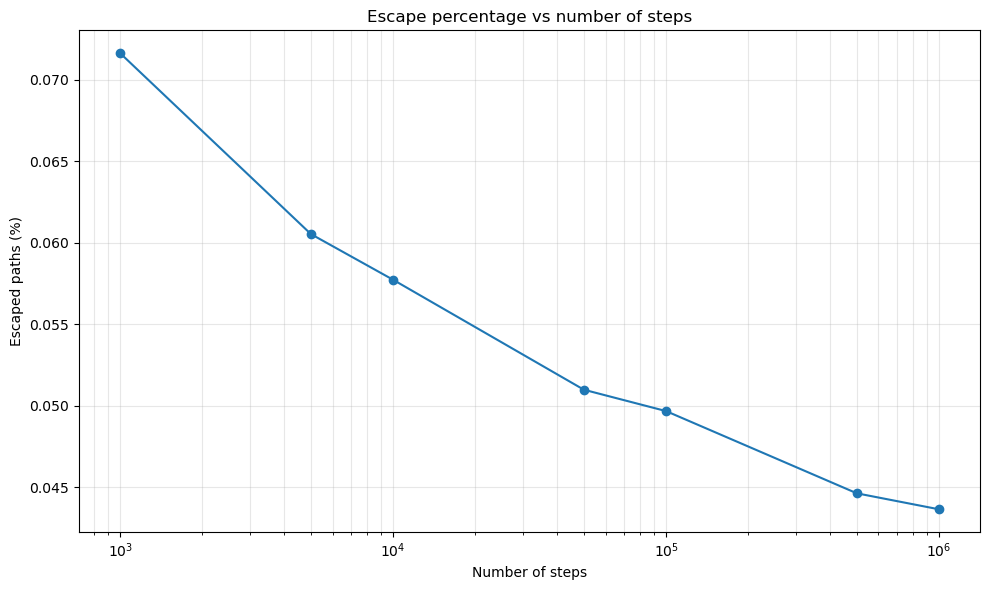

In [9]:
# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.semilogx(step_grid[6:], escape_percentages[6:], marker="o")
plt.xlabel("Number of steps")
plt.ylabel("Escaped paths (%)")
plt.title("Escape percentage vs number of steps")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()